In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

dataset = rasterio.open('../data/gujarat_sar.tif')

band1 = dataset.read(1)

print(band1.shape)

(223, 208)


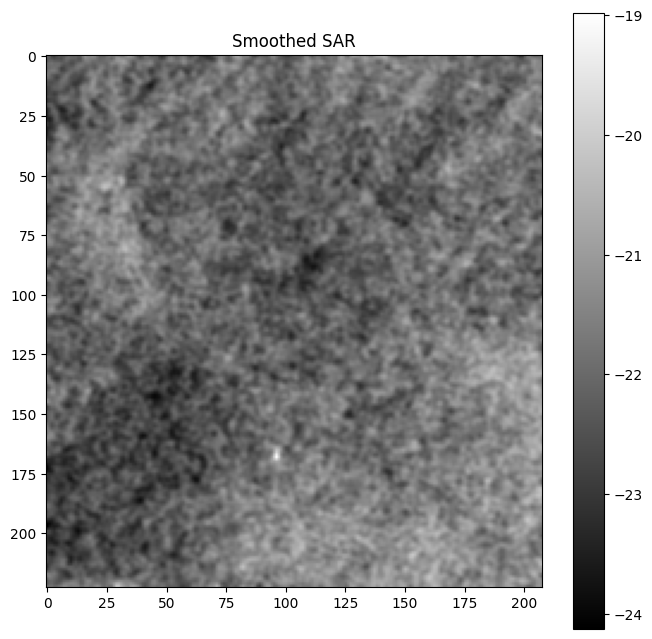

In [2]:
from scipy.ndimage import gaussian_filter

clipped_band = np.clip(band1, -25, -10)

smoothed = gaussian_filter(
    clipped_band,
    sigma=1
)

plt.figure(figsize=(8,8))

plt.imshow(smoothed, cmap='gray')

plt.colorbar()

plt.title("Smoothed SAR")

plt.show()

In [3]:
print("Mean:", np.mean(smoothed))
print("Std:", np.std(smoothed))

print("P25:", np.percentile(smoothed, 25))
print("P50:", np.percentile(smoothed, 50))
print("P75:", np.percentile(smoothed, 75))

Mean: -21.943196236874606
Std: 0.5573709248317009
P25: -22.326684388561965
P50: -21.946545154178857
P75: -21.556703779658577


In [4]:
grad_y, grad_x = np.gradient(smoothed)

gradient_magnitude = np.sqrt(
    grad_x**2 + grad_y**2
)

print("Gradient Mean:", np.mean(gradient_magnitude))
print("Gradient Std:", np.std(gradient_magnitude))

Gradient Mean: 0.22394038967101365
Gradient Std: 0.11943018279481615


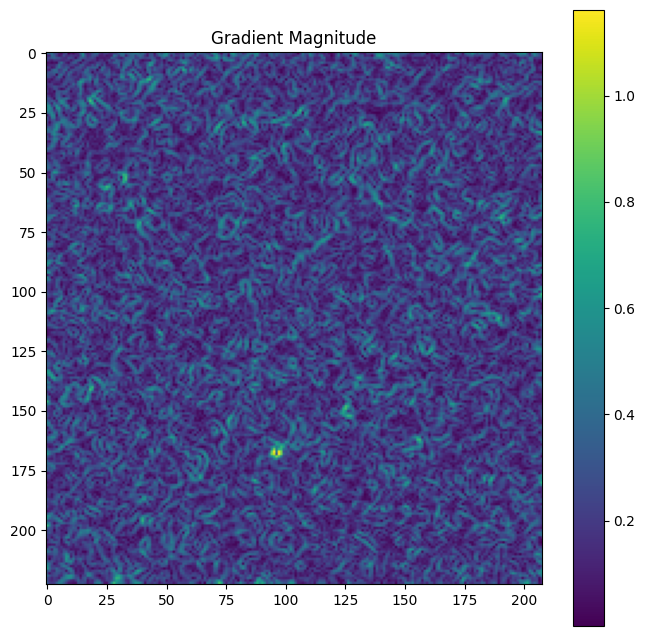

In [5]:
plt.figure(figsize=(8,8))

plt.imshow(
    gradient_magnitude,
    cmap='viridis'
)

plt.colorbar()

plt.title("Gradient Magnitude")

plt.show()

In [6]:
from scipy.ndimage import generic_filter

roughness = generic_filter(
    smoothed,
    np.std,
    size=5
)

print("Roughness Mean:", np.mean(roughness))
print("Roughness Std:", np.std(roughness))

Roughness Mean: 0.2619394560702332
Roughness Std: 0.0834547356896552


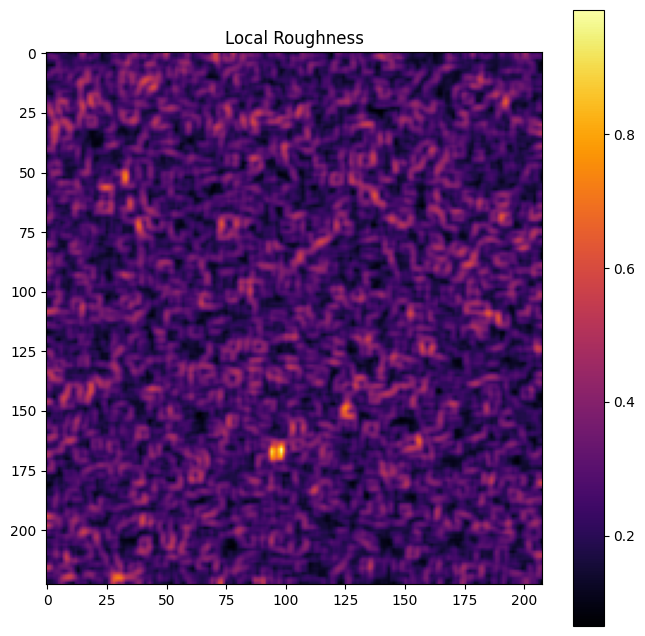

In [7]:
plt.figure(figsize=(8,8))

plt.imshow(
    roughness,
    cmap='inferno'
)

plt.colorbar()

plt.title("Local Roughness")

plt.show()

In [8]:
edges = gradient_magnitude > np.mean(
    gradient_magnitude
)

edge_density = np.sum(edges) / edges.size

print("Edge Density:", edge_density)

Edge Density: 0.4535831321145222
